<a href="https://colab.research.google.com/github/ktripa/DL_Hydrology/blob/main/SPI_6_SARIMA_class.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# Author: Kumar Puran Tripathy (PhD, CEWS lab)
# Class: Hydroclimatic Extremes
# Instructor: Ashok Kumar Mishra
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║                       ARIMA TIME SERIES ANALYSIS                            ║
# ║     Date-based Split (Train: 1901–1989 | Test: 1990–2018)                    ║
# ║         Original Series | ACF/PACF | (Next: Differencing & ARIMA)            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ─── 0. INSTALL & IMPORT ──────────────────────────────────────────────────────
# !pip install statsmodels openpyxl


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools    import adfuller, acf, pacf
from statsmodels.tsa.arima.model  import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy                        import stats

# ─── GLOBAL STYLE ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f172a', 'axes.facecolor':   '#1e293b',
    'axes.edgecolor':   '#475569', 'axes.labelcolor':  '#e2e8f0',
    'xtick.color':      '#94a3b8', 'ytick.color':      '#94a3b8',
    'text.color':       '#e2e8f0', 'grid.color':       '#334155',
    'grid.linestyle':   '--',      'grid.alpha':        0.5,
    'font.family':      'monospace','axes.titlesize':   11,
    'axes.labelsize':   10,        'legend.facecolor': '#1e293b',
    'legend.edgecolor': '#475569',
})
AMBER  = '#f59e0b'; GREEN  = '#34d399'; BLUE  = '#60a5fa'
ROSE   = '#f87171'; PURPLE = '#a78bfa'; SLATE = '#94a3b8'
LEAD_COLORS = ['#f87171','#fb923c','#fbbf24','#34d399','#38bdf8','#c084fc']
LEAD_LABELS = ['Lead-1','Lead-2','Lead-3','Lead-4','Lead-5','Lead-6']

# ─── HELPER: custom ACF/PACF plot ─────────────────────────────────────────────
def styled_acf_pacf(series, title, filename, nlags=40, color=BLUE):
    series = series.dropna()
    acf_vals,  acf_ci  = acf (series, nlags=nlags, alpha=0.05)
    pacf_vals, pacf_ci = pacf(series, nlags=nlags, alpha=0.05, method='ywm')
    lags = np.arange(nlags + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(title, fontsize=12, color=AMBER, fontweight='bold')

    for ax, vals, ci, lbl in [
        (axes[0], acf_vals, acf_ci, 'ACF'),
        (axes[1], pacf_vals, pacf_ci, 'PACF')
    ]:
        cil = ci[:, 0] - vals
        ciu = ci[:, 1] - vals
        ax.fill_between(lags, cil, ciu, alpha=0.15, color=AMBER, label='95% CI')
        ax.axhline(0, color='#475569', lw=1)
        for lag in lags[1:]:
            c = ROSE if (vals[lag] < cil[lag] or vals[lag] > ciu[lag]) else SLATE
            ax.vlines(lag, 0, vals[lag], colors=c, lw=2)
            ax.plot(lag, vals[lag], 'o', color=c, ms=5, zorder=3)
        ax.vlines(0, 0, vals[0], colors=SLATE, lw=2)
        ax.plot(0, vals[0], 'o', color=SLATE, ms=5)
        ax.set_xlabel('Lag'); ax.set_ylabel(lbl)
        ax.set_title(f'{lbl}', color=color, fontweight='bold')
        ax.set_xlim(-0.5, nlags + 0.5)
        ax.grid(True, alpha=0.3); ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight', facecolor='#0f172a')
    plt.show(); print(f"  ✓ Saved: {filename}")




In [4]:
from google.colab import files
uploaded = files.upload()

Saving Climate division 1.xlsx to Climate division 1.xlsx



  Training : 1980-01-01 → 2009-12-01  (360 months)
  Test     : 2010-01-01  → 2018-11-01  (107 months)
  Train stats: mean=0.123  std=0.910  min=-2.090  max=2.570


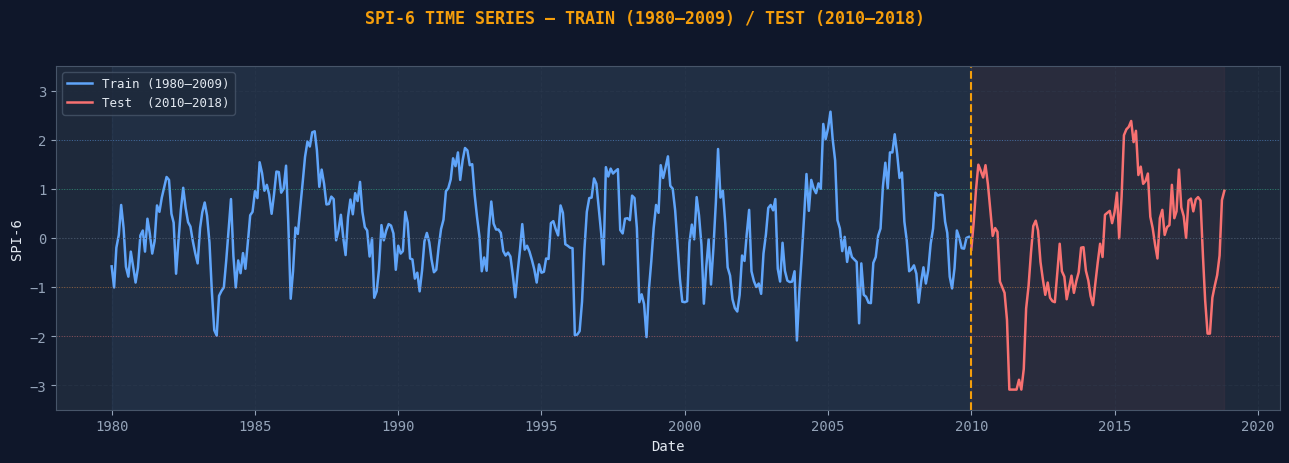

In [9]:


df_raw = pd.read_excel('Climate division 1.xlsx', header=0)
if any(str(c).startswith("Unnamed") for c in df_raw.columns):
    df_raw.columns = df_raw.iloc[0]
    df_raw = df_raw.drop(0).reset_index(drop=True)

df = df_raw.copy()
df['YearMonth'] = df['YearMonth'].astype(str).str.strip()
df['Year']  = df['YearMonth'].str[:4].astype(int)
df['Month'] = df['YearMonth'].str[4:].astype(int)
df['Date']  = pd.to_datetime(dict(year=df['Year'], month=df['Month'], day=1))
df = df.sort_values('Date').set_index('Date')
df = df.replace([-99.99, -9999, -999.9, -99.9], np.nan)

y = df['SP06'].astype(float)
train = y.loc['1980-01-01':'2009-12-01'].dropna()
test  = y.loc['2010-01-01':].dropna()
n_train = len(train); n_test = len(test)

print(f"\n  Training : {train.index.min().date()} → {train.index.max().date()}  ({n_train} months)")
print(f"  Test     : {test.index.min().date()}  → {test.index.max().date()}  ({n_test} months)")
print(f"  Train stats: mean={train.mean():.3f}  std={train.std():.3f}  "
      f"min={train.min():.3f}  max={train.max():.3f}")

fig, ax = plt.subplots(figsize=(13, 4.5))
fig.suptitle('SPI-6 TIME SERIES — TRAIN (1980–2009) / TEST (2010–2018)',
             fontsize=12, color=AMBER, fontweight='bold', y=1.02)
ax.plot(train.index, train.values, color=BLUE, lw=1.8, label='Train (1980–2009)')
ax.plot(test.index,  test.values,  color=ROSE, lw=1.8, label='Test  (2010–2018)')
split_date = pd.to_datetime('2010-01-01')
ax.axvline(split_date, color=AMBER, lw=1.5, ls='--')
ax.axhline(0, color='#475569', lw=0.8, ls=':')
ax.fill_betweenx([-3.5, 3.5], train.index.min(), split_date, alpha=0.05, color=BLUE)
ax.fill_betweenx([-3.5, 3.5], split_date, test.index.max(),  alpha=0.05, color=ROSE)
# SPI threshold lines
for val, lbl, c in [(-2,'Extreme Dry',ROSE),(-1,'Moderate Dry','#fb923c'),
                     (1,'Moderate Wet',GREEN),(2,'Extreme Wet',BLUE)]:
    ax.axhline(val, color=c, lw=0.7, ls=':', alpha=0.5)
ax.set_ylabel('SPI-6'); ax.set_xlabel('Date')
ax.legend(fontsize=9, loc='upper left'); ax.grid(True, alpha=0.3)
ax.set_ylim(-3.5, 3.5)
plt.tight_layout()
# plt.savefig('01_spi6_train_test_split.png', dpi=150, bbox_inches='tight', facecolor='#0f172a')



  SECTION 2: ACF & PACF + ADF TEST (Training Set, d=0)


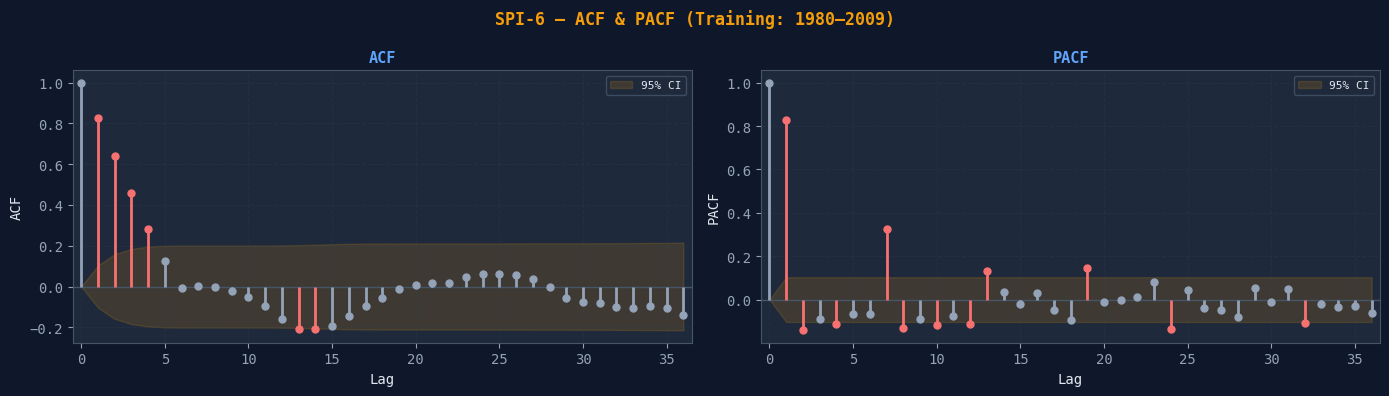

  ✓ Saved: 02_spi6_acf_pacf_train.png


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 2 — ACF / PACF + ADF TEST (TRAINING DATA)
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  SECTION 2: ACF & PACF + ADF TEST (Training Set, d=0)")
print("=" * 70)

styled_acf_pacf(train, 'SPI-6 — ACF & PACF (Training: 1980–2009)',
                '02_spi6_acf_pacf_train.png', nlags=36, color=BLUE)

adf = adfuller(train, autolag='AIC')



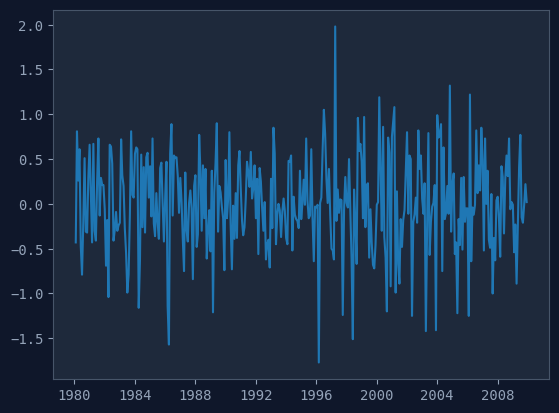

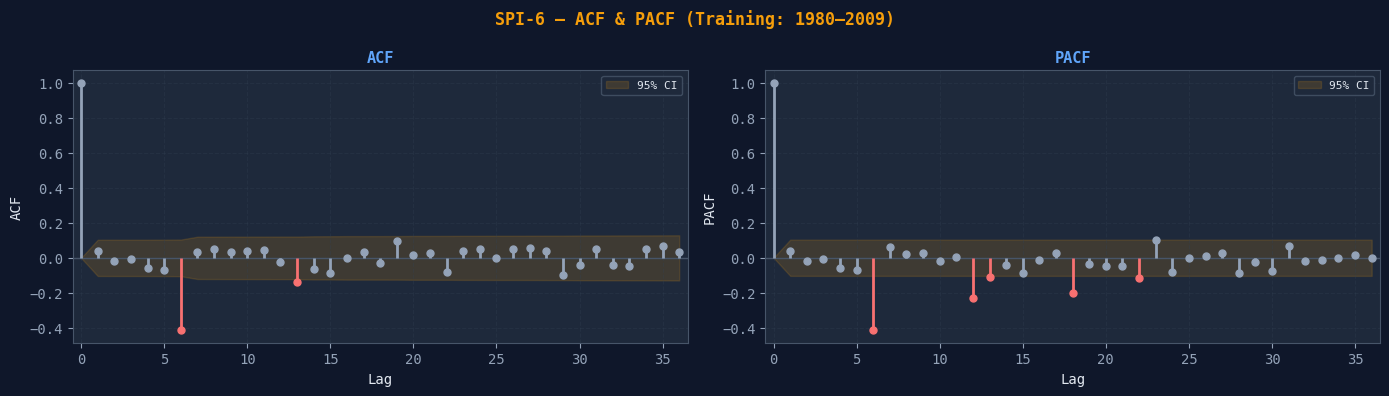

  ✓ Saved: 02_spi6_acf_pacf_train.png


In [16]:
train_diff1 = train.diff().dropna()
plt.plot(train_diff1)
styled_acf_pacf(train_diff1, 'SPI-6 — ACF & PACF (Training: 1980–2009)',
                '02_spi6_acf_pacf_train.png', nlags=36, color=BLUE)


  Model (p,d,q)(P,D,Q,s)              AIC        BIC       HQIC     LogLik         σ²
  ──────────────────────────────────────────────────────────────────────────
  SARIMA(1, 1, 0)(0, 0, 1, 6)     459.580    471.171    464.193   -226.790     0.2143
  SARIMA(2, 1, 0)(0, 0, 1, 6)     460.120    475.575    466.270   -226.060     0.2132
  SARIMA(1, 1, 0)(1, 0, 0, 6)     493.522    505.112    498.134   -243.761     0.2364
  SARIMA(2, 1, 0)(1, 0, 0, 6)     491.780    507.223    497.926   -241.890     0.2362
  SARIMA(0, 1, 1)(0, 0, 1, 6)     458.487    470.070    463.097   -226.244     0.2145
  SARIMA(0, 1, 2)(0, 0, 1, 6)     458.961    474.393    465.104   -225.481     0.2140
  SARIMA(0, 1, 1)(1, 0, 0, 6)     494.505    506.104    499.121   -244.253     0.2365
  SARIMA(1, 1, 1)(0, 0, 1, 6)     460.012    475.455    466.158   -226.006     0.2173
  SARIMA(1, 1, 1)(1, 0, 0, 6)     492.996    508.451    499.147   -242.498     0.2390
  SARIMA(2, 1, 1)(0, 0, 1, 6)     450.052    469.356    457.73

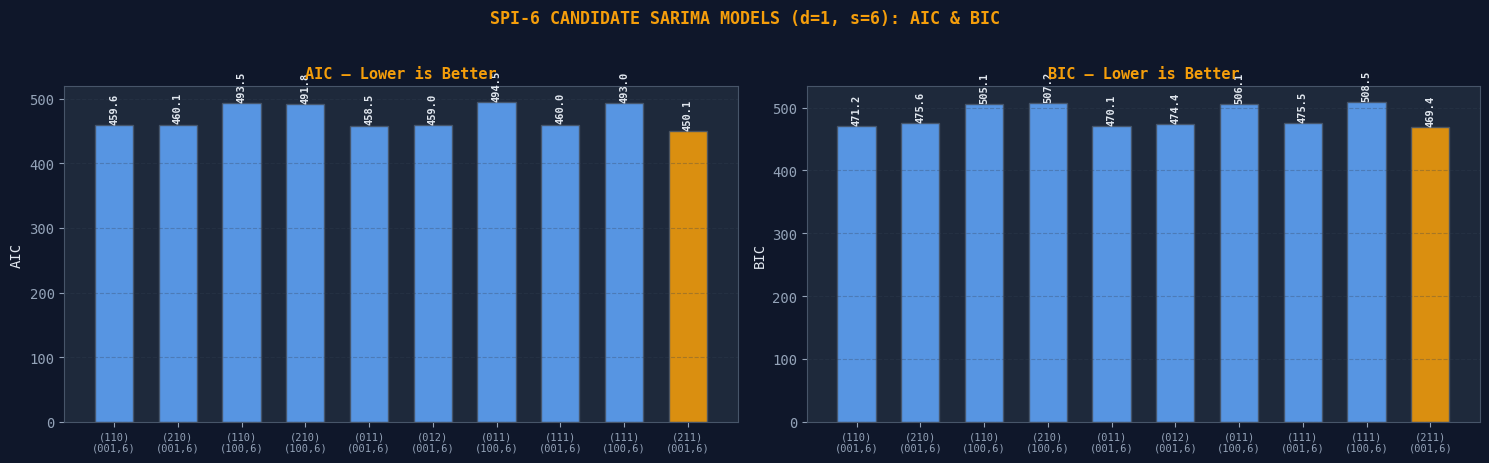

  ✓ Saved: 03_spi6_sarima_model_comparison.png


In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 3 — SPI-6 CANDIDATE SARIMA MODELS (d=1, s=6): AIC / BIC
# ══════════════════════════════════════════════════════════════════════════════
# After d=1 differencing:
#   - Mean ≈ 0, constant variance  → stationary ✓
#   - ACF: negative spike at lag 6       → seasonal MA(1) at s=6
#   - PACF: negative spikes at 6,12,18   → seasonal AR component at s=6
#   - Regular part: mostly white noise after lag 0 → low p,q
#   - Seasonal period s=6 (SPI-6 has 6-month rolling window → natural cycle)
#
# Candidate structure: SARIMA(p, 1, q)(P, 0, Q)_6
#   d=1   → regular differencing confirmed by ADF + visual
#   D=0   → seasonal differencing NOT needed (d=1 already stabilised mean)
#   s=6   → seasonal period = 6 months
# ──────────────────────────────────────────────────────────────────────────────

from statsmodels.tsa.statespace.sarimax import SARIMAX

# (p, d, q) , (P, D, Q, s)
candidate_orders = [
    # ── Non-seasonal AR dominant (PACF spike at lag 1) ──────────────────
    ((1,1,0), (0,0,1,6)),   # AR(1) + seasonal MA(1)        ← strong candidate
    ((2,1,0), (0,0,1,6)),   # AR(2) + seasonal MA(1)
    ((1,1,0), (1,0,0,6)),   # AR(1) + seasonal AR(1)
    ((2,1,0), (1,0,0,6)),   # AR(2) + seasonal AR(1)

    # ── MA non-seasonal ──────────────────────────────────────────────────
    ((0,1,1), (0,0,1,6)),   # MA(1) + seasonal MA(1)
    ((0,1,2), (0,0,1,6)),   # MA(2) + seasonal MA(1)
    ((0,1,1), (1,0,0,6)),   # MA(1) + seasonal AR(1)

    # ── Mixed ARMA ───────────────────────────────────────────────────────
    ((1,1,1), (0,0,1,6)),   # ARMA(1,1) + seasonal MA(1)   ← strong candidate
    ((1,1,1), (1,0,0,6)),   # ARMA(1,1) + seasonal AR(1)
    ((2,1,1), (0,0,1,6)),   # ARMA(2,1) + seasonal MA(1)
]

model_results = {}

print(f"\n  {'Model (p,d,q)(P,D,Q,s)':<28} {'AIC':>10} {'BIC':>10} "
      f"{'HQIC':>10} {'LogLik':>10} {'σ²':>10}")
print("  " + "─" * 74)

for (order, seasonal_order) in candidate_orders:
    try:
        mod = SARIMAX(train,
                      order=order,
                      seasonal_order=seasonal_order,
                      enforce_stationarity=False,
                      enforce_invertibility=False).fit(disp=False)
        sig2 = np.var(mod.resid)
        label = f"SARIMA{order}{seasonal_order}"
        model_results[(order, seasonal_order)] = mod
        print(f"  {label:<28} {mod.aic:>10.3f} {mod.bic:>10.3f} "
              f"{mod.hqic:>10.3f} {mod.llf:>10.3f} {sig2:>10.4f}")
    except Exception as e:
        print(f"  SARIMA{order}{seasonal_order:<20} FAILED: {e}")

# Best by AIC
best_key = min(model_results, key=lambda k: model_results[k].aic)
best_order, best_seasonal = best_key
print(f"\n  ✓ Best model by AIC : SARIMA{best_order}{best_seasonal}")
print(f"  ✓ Best model by BIC : SARIMA"
      f"{min(model_results, key=lambda k: model_results[k].bic)}")

# ── AIC / BIC bar chart ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
fig.suptitle('SPI-6 CANDIDATE SARIMA MODELS (d=1, s=6): AIC & BIC',
             fontsize=12, color=AMBER, fontweight='bold', y=1.02)

labels   = [f"({o[0]}{o[1]}{o[2]})\n({s[0]}{s[1]}{s[2]},{s[3]})"
            for o, s in candidate_orders if (o,s) in model_results]
keys_ok  = [(o,s) for o,s in candidate_orders if (o,s) in model_results]
aic_vals = [model_results[k].aic for k in keys_ok]
bic_vals = [model_results[k].bic for k in keys_ok]
bar_cols = [AMBER if k == best_key else BLUE for k in keys_ok]

for ax, vals, metric in [(axes[0], aic_vals, 'AIC'),
                          (axes[1], bic_vals, 'BIC')]:
    bars = ax.bar(range(len(labels)), vals, color=bar_cols,
                  edgecolor='#475569', width=0.6, alpha=0.88)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                v + 0.04*(max(vals)-min(vals)),
                f'{v:.1f}', ha='center', va='bottom', fontsize=7.5,
                color='#e2e8f0', fontweight='bold', rotation=90)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=7.5)
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} — Lower is Better', color=AMBER, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('03_spi6_sarima_model_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='#0f172a')
plt.show()
print("  ✓ Saved: 03_spi6_sarima_model_comparison.png")